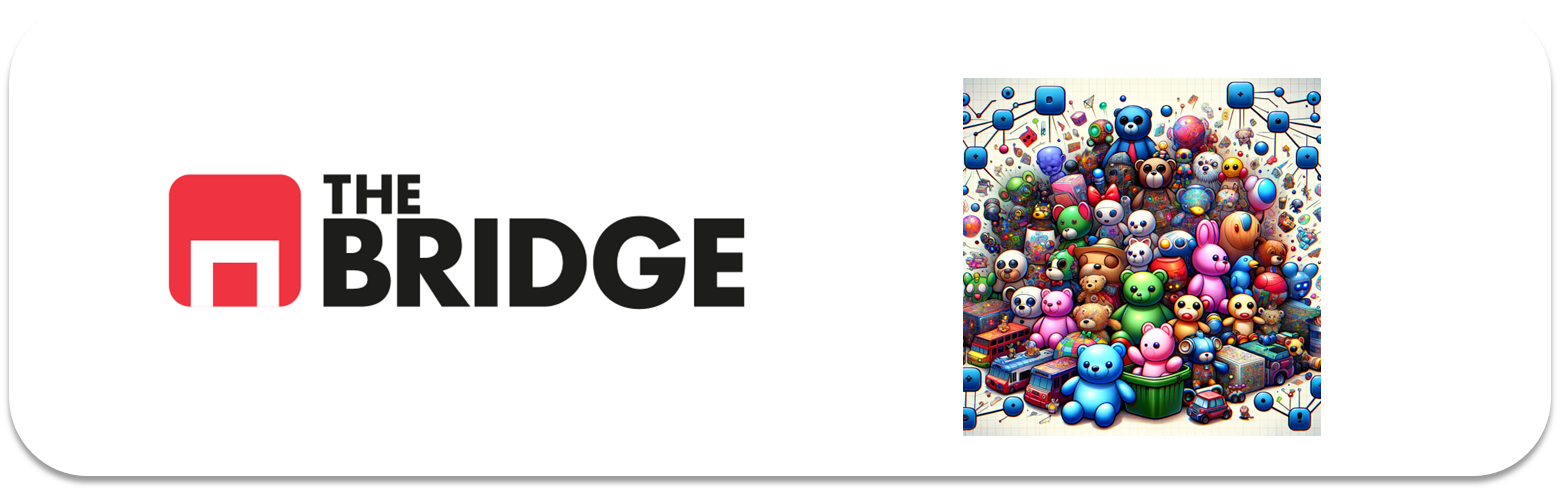

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

from itertools import combinations

# Clustering no jerarquico (DBSCAN) y jerarquico (Aglomerativo)
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Para "predecir" con DBSCAN necesitamos un clasificador (DBSCAN no tiene predict)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

import bootcampviztools as bt

import warnings
warnings.filterwarnings("ignore")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


#### 1. Entender el problema

Nos piden **segmentar** mezclas de bebidas energeticas. Puntos clave del enunciado:

* **No hay target** (no se hicieron tests con usuarios) -> es un problema **NO supervisado** -> clustering.
* Por tanto **NO hay split train/test** (no hay nada contra lo que validar).
* Los quimicos esperan **entre 3 y 5 segmentos** -> es nuestra "nota orientativa" para elegir hiperparametros.
* Quieren **relacion entre segmentos** (cuales se parecen mas entre si) -> eso lo da un **clustering jerarquico**
  (el dendrograma nos dice a que distancia se unen los clusters). Por eso el segundo algoritmo que pide el
  enunciado "deberia estar claro cual es": el **Aglomerativo**.

Asi que haremos: **DBSCAN** + **Clustering Jerarquico Aglomerativo**.

#### 2. Cargar datos y visualizar

In [2]:
# Ojo: el fichero viene separado por "|"
train_set = pd.read_csv("./data/empowering_drinks.csv", sep="|")
print("Shape:", train_set.shape)
train_set.head()

Shape: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [3]:
train_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [4]:
train_set.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


*Fijate en el `describe`: todas las features tienen **media ~0 y desviacion ~1**. Es decir, los quimicos
ya nos han dado los datos **escalados** (estandarizados). Esto es importante porque el clustering usa
**distancias** y es muy sensible a la escala. Como ya estan escaladas, no tenemos que escalar nosotros.*

In [5]:
# Comprobamos que no hay nulos
print("Nulos por columna:")
print(train_set.isna().sum())

Nulos por columna:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


#### 3. MiniEDA: seleccion de features

*En no supervisado el miniEDA no busca la relacion con el target (no hay), busca:*
*1) ver si hay que escalar/transformar, 2) codificar categoricas, 3) ver si con 2-3 features ya se intuyen agrupaciones.*

*Aqui no hay categoricas y ya estan escaladas, asi que vamos directos al punto 3: visualizar de dos en dos.*

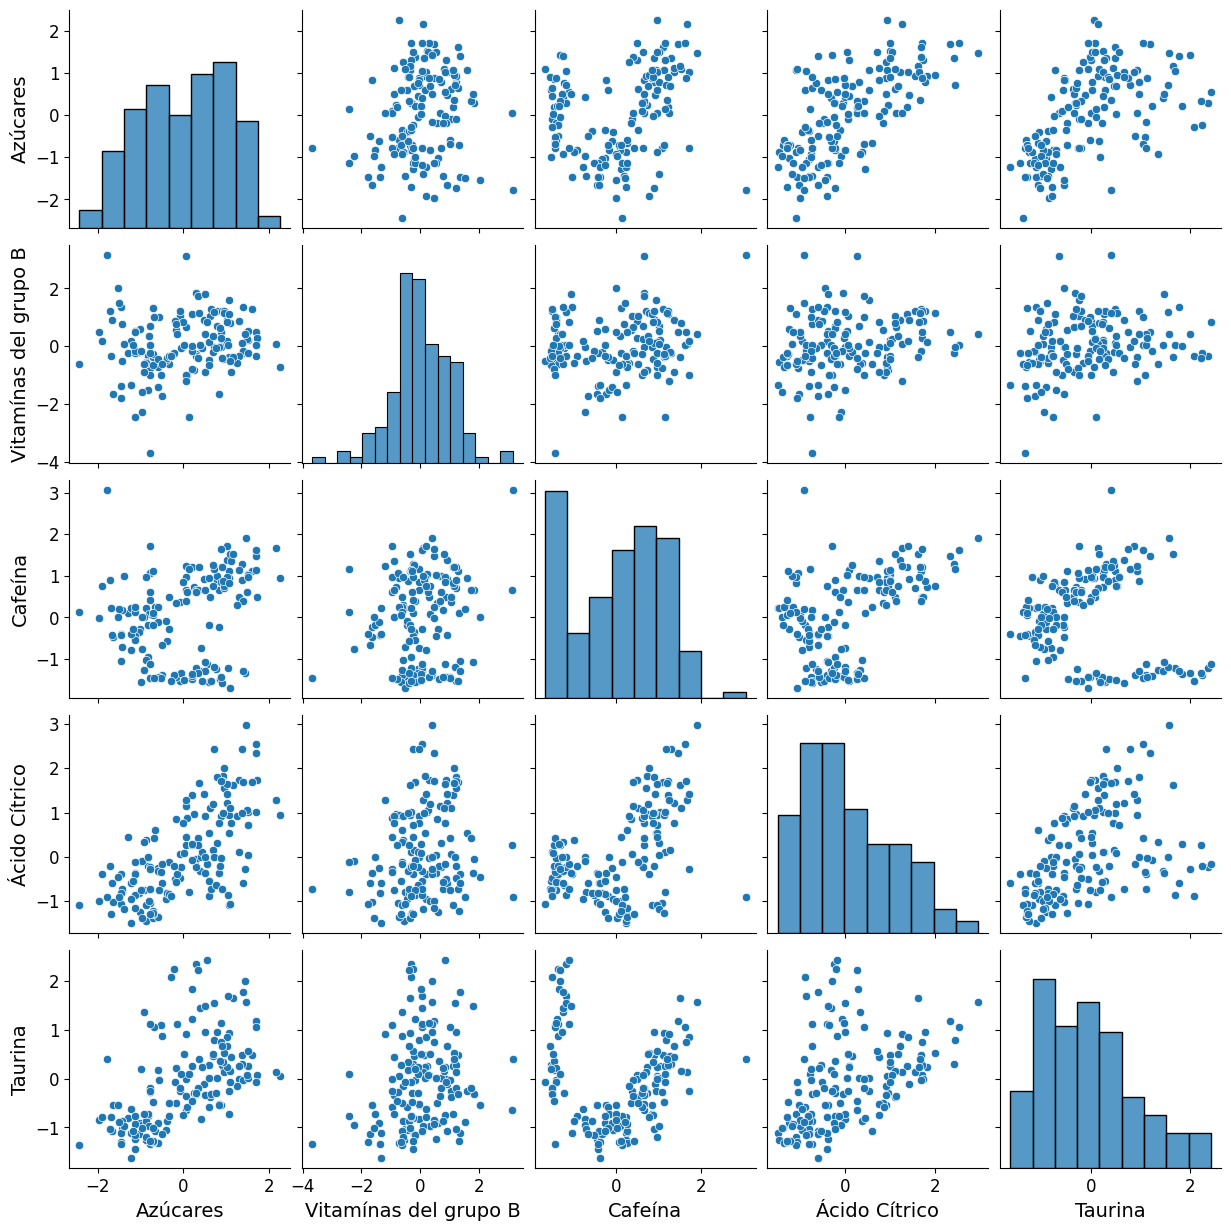

In [6]:
# Vista general de todas las parejas
sns.pairplot(train_set)
plt.show()

*A simple vista cuesta ver "manchas" (blobs) separadas, que es lo que le gustaria a un KMeans.
Miremos pareja a pareja con mas detalle usando la herramienta del curso.*

Azúcares vs Vitamínas del grupo B


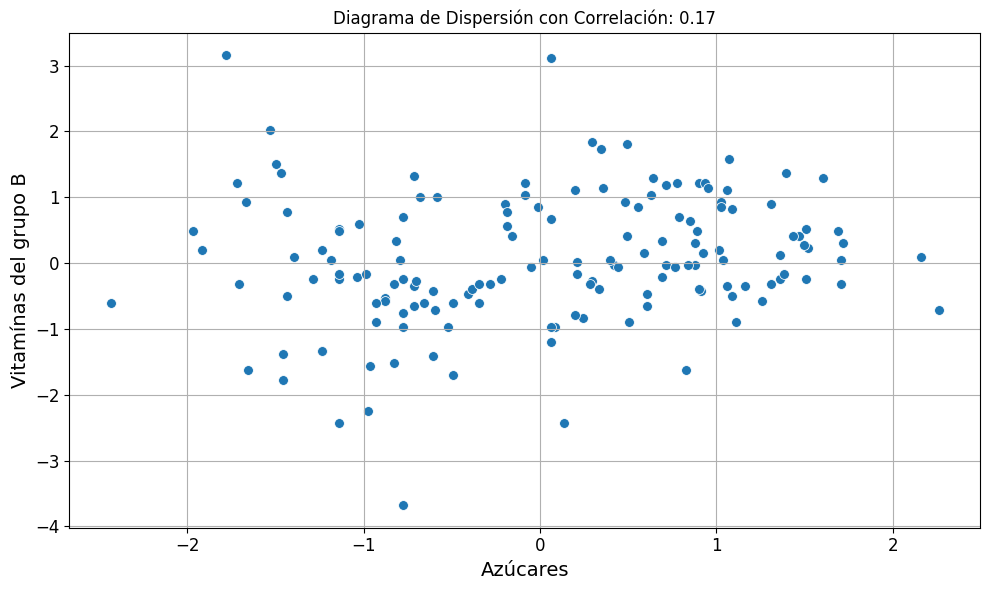

Azúcares vs Cafeína


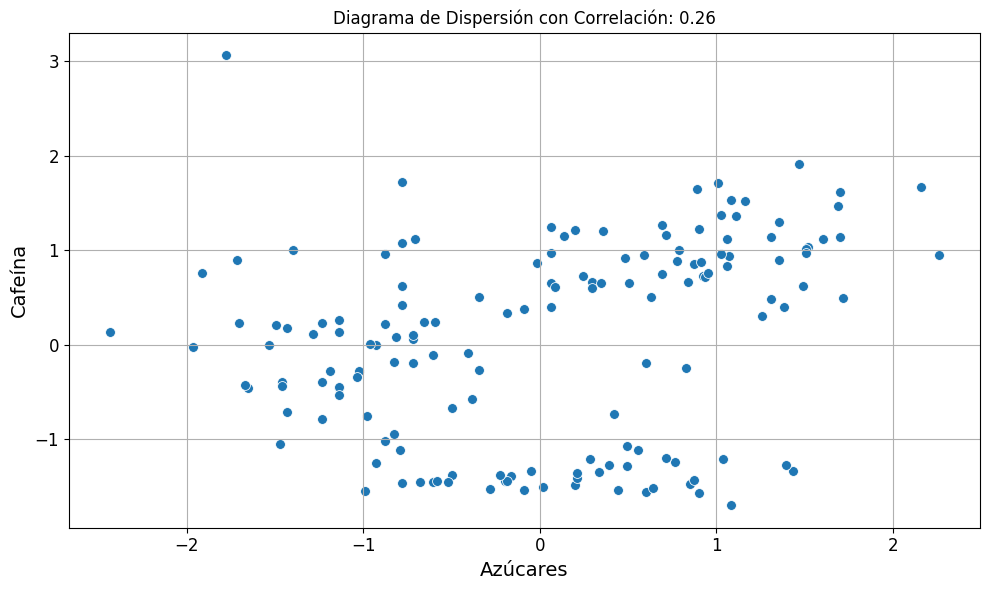

Azúcares vs Ácido Cítrico


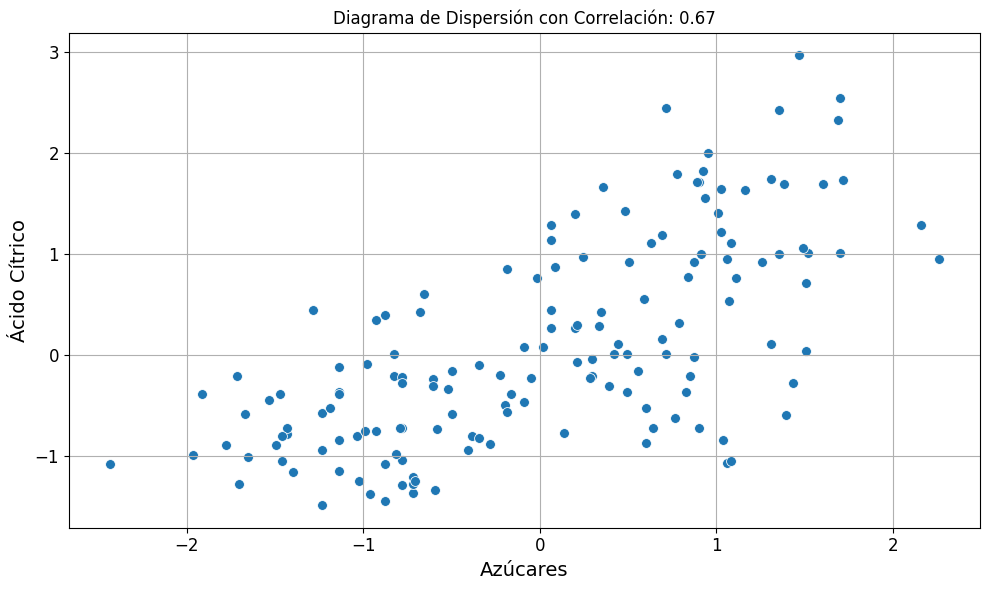

Azúcares vs Taurina


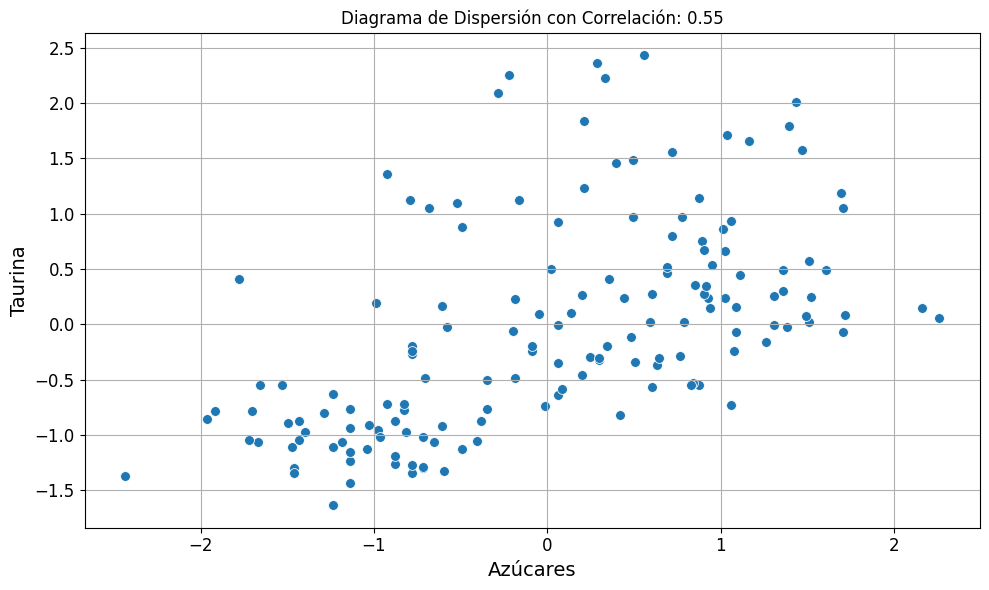

Vitamínas del grupo B vs Cafeína


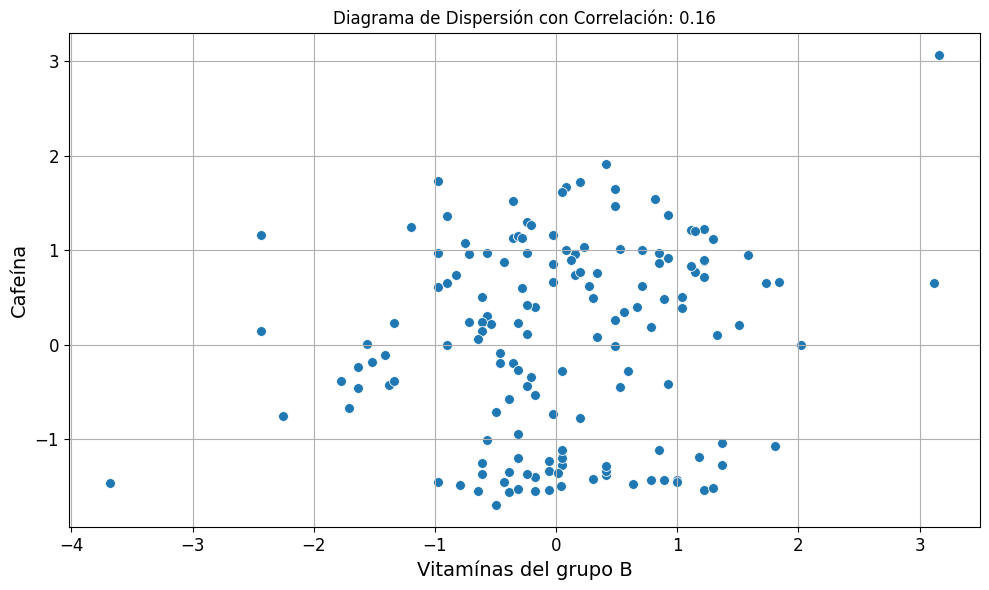

Vitamínas del grupo B vs Ácido Cítrico


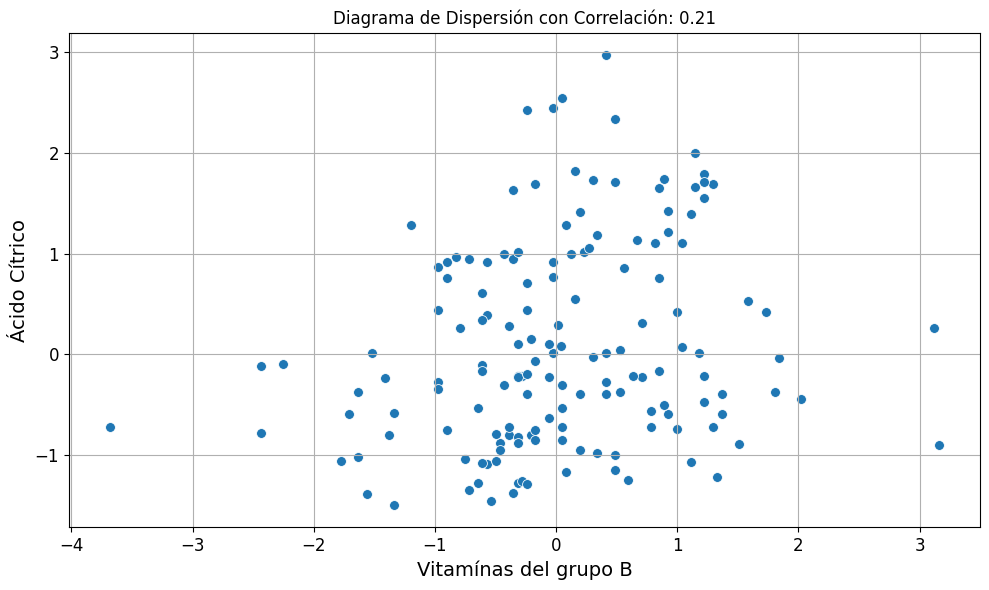

Vitamínas del grupo B vs Taurina


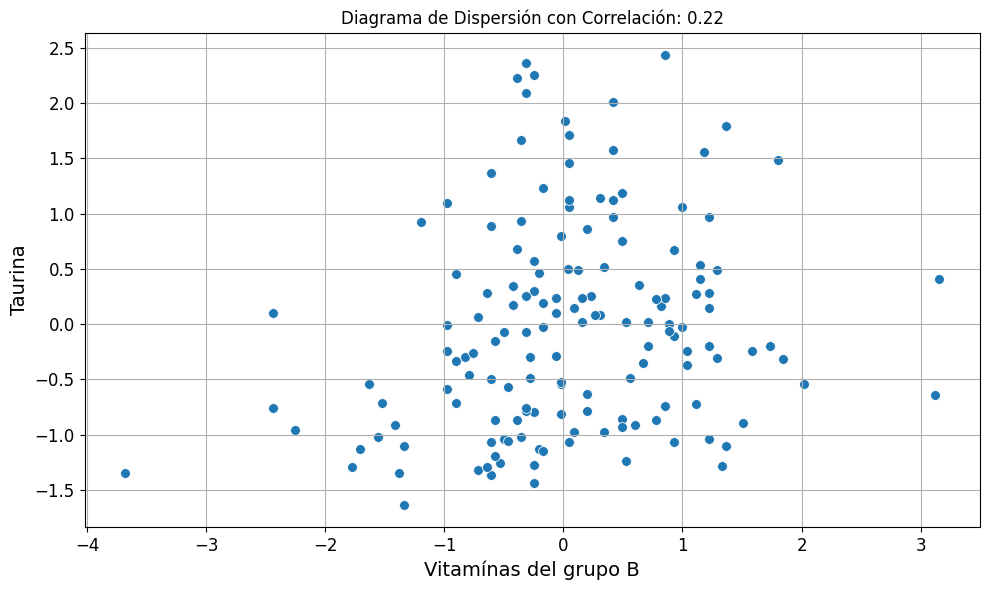

Cafeína vs Ácido Cítrico


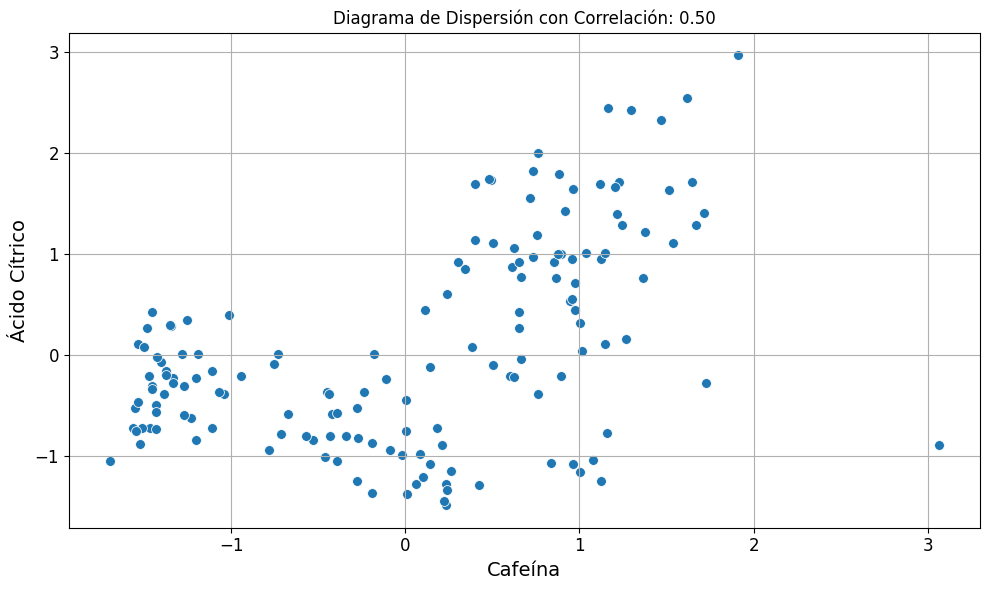

Cafeína vs Taurina


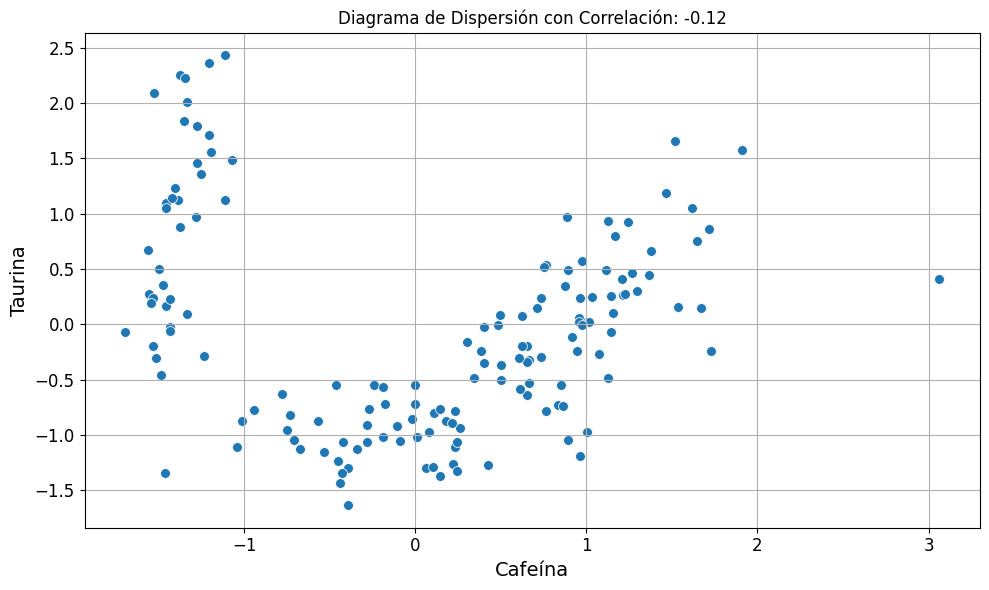

Ácido Cítrico vs Taurina


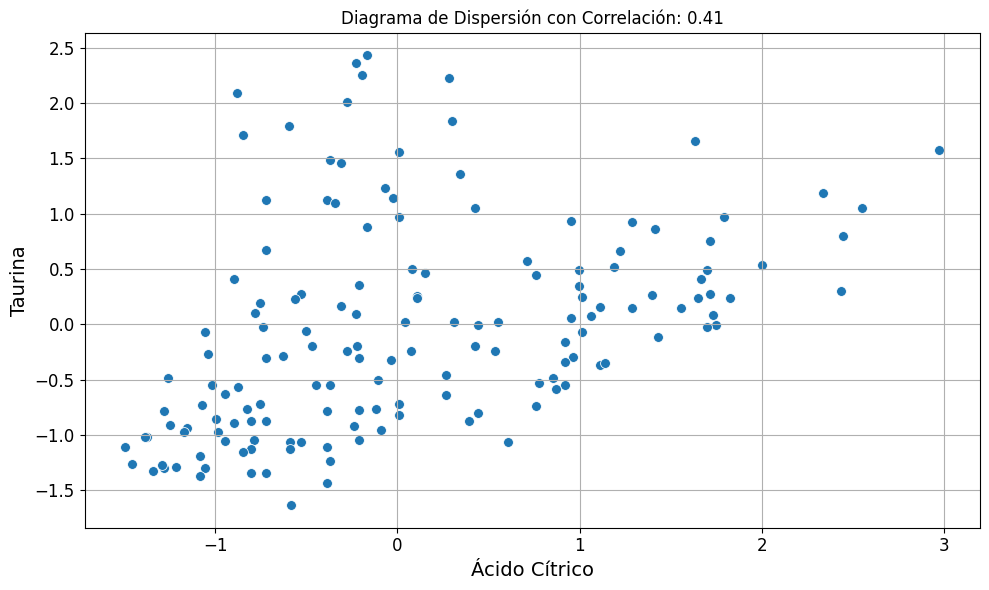

In [7]:
# Todas las combinaciones de features de 2 en 2
for x, y in combinations(train_set.columns, r=2):
    print(f"{x} vs {y}")
    bt.grafico_dispersion_con_correlacion(train_set, x, y, mostrar_correlacion=True)

*El par **Cafeina - Taurina** es el que muestra unas agrupaciones mas claras y separadas
(se ven "brazos"/zonas densas). Nos quedamos con esas dos features: ademas de que el clustering
saldra mejor, el modelo sera mas simple y mucho mas **explicable** para los quimicos (que es lo que nos piden).*

In [8]:
features = train_set.columns.to_list()          # todas, por si queremos comparar
features_short = ["Cafeína", "Taurina"]        # las dos que hemos elegido
features_short

['Cafeína', 'Taurina']

#### 4. Tratamiento de features

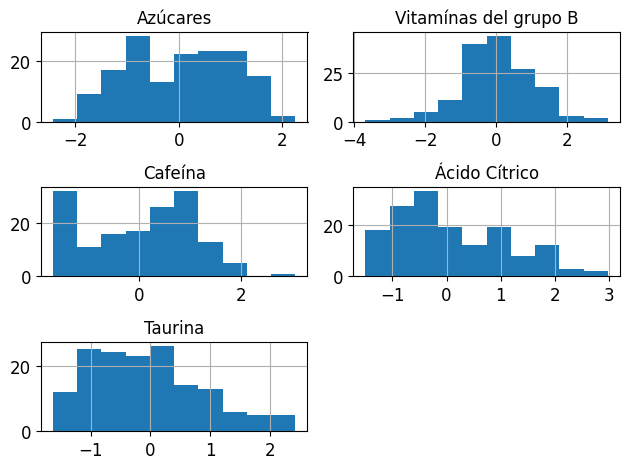

In [9]:
# Miramos las distribuciones por si hubiera que transformar algo
train_set.hist()
plt.tight_layout()
plt.show()

*Las distribuciones son razonables y, como vimos en el `describe`, los datos **ya estan escalados**.
No tocamos nada mas.*

#### 5. Seleccion de modelos y de hiperparametros

**DBSCAN**: sus dos hiperparametros son `eps` (radio del vecindario) y `min_samples` (vecinos minimos
para ser "core"). Como no tenemos target, el criterio para elegirlos sera:
* que salgan **entre 3 y 5 clusters** (la nota de los quimicos), y
* que el **porcentaje de anomalias** (-1) sea razonablemente bajo.

Vamos a barrer `eps` para varios `min_samples` y ver el % de anomalias, primero con TODAS las features.

In [10]:
# Barrido de eps para varios min_samples, con TODAS las features
experiments = {}

for min_samples in [3, 5, 10]:
    outlier_percent = []
    for eps in np.linspace(0.001, 6, 100):     # 100 valores equidistantes entre 0.001 y 6
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set)
        # Las anomalias se etiquetan como -1
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent
    print(f"min_samples = {min_samples} -> barrido hecho")

min_samples = 3 -> barrido hecho


min_samples = 5 -> barrido hecho


min_samples = 10 -> barrido hecho


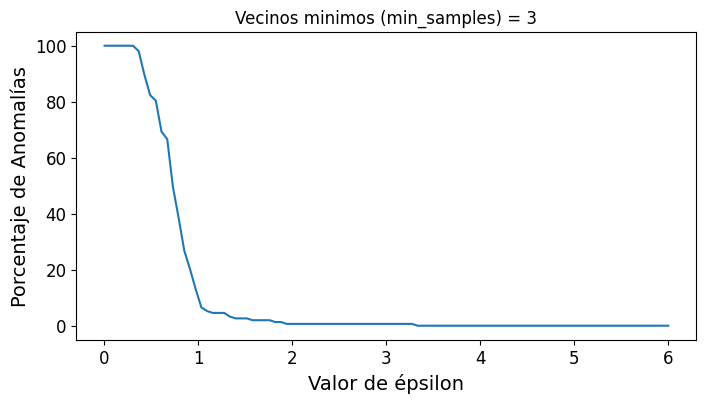

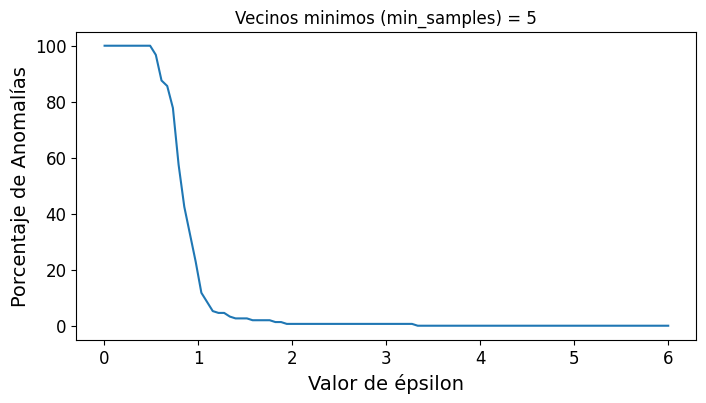

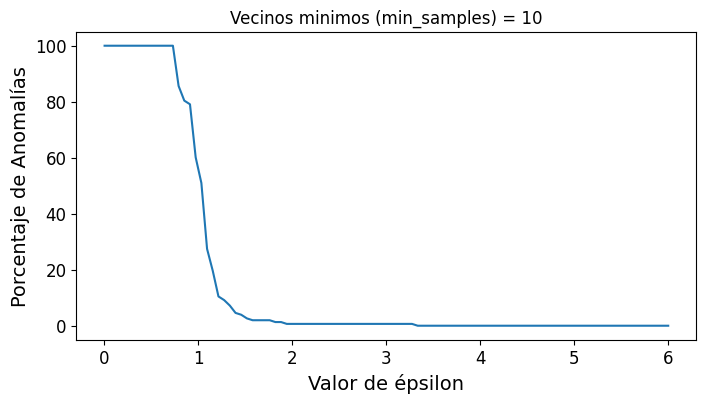

In [11]:
for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4), dpi=100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel("Porcentaje de Anomalías")
    plt.xlabel("Valor de épsilon")
    plt.title(f"Vecinos minimos (min_samples) = {min_samples}")
    plt.show()

*El % de anomalias cae en picado y se estabiliza. Pero un % bajo de anomalias no significa un buen
clustering: si `eps` es muy grande, todo acaba en UN solo cluster. Comprobemoslo.*

In [12]:
# Con eps grande: pocas anomalias pero... ¿cuantos clusters?
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.3, min_samples=min_samples)
    dbscan.fit(train_set)
    n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
    print(f"eps=1.3, min_samples={min_samples} -> {n_clusters} clusters")

eps=1.3, min_samples=3 -> 1 clusters
eps=1.3, min_samples=5 -> 1 clusters
eps=1.3, min_samples=10 -> 1 clusters


*Efectivamente: **1 solo cluster**. No nos sirve. Bajamos el eps.*

In [13]:
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.0, min_samples=min_samples)
    dbscan.fit(train_set)
    n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
    perc = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
    print(f"eps=1.0, min_samples={min_samples} -> {n_clusters} clusters, {perc:.1f}% anomalias")

eps=1.0, min_samples=3 -> 4 clusters, 9.2% anomalias
eps=1.0, min_samples=5 -> 3 clusters, 18.3% anomalias
eps=1.0, min_samples=10 -> 2 clusters, 57.5% anomalias


*Con las 5 features nos movemos entre 2 y 4 clusters. Pero recuerda que en el miniEDA vimos que las
agrupaciones se veian sobre todo en **Cafeina-Taurina**. En 5 dimensiones las distancias se "diluyen"
(la maldicion de la dimensionalidad). Repitamos el barrido usando SOLO esas dos features.*

min_samples = 3 -> barrido hecho


min_samples = 5 -> barrido hecho


min_samples = 10 -> barrido hecho


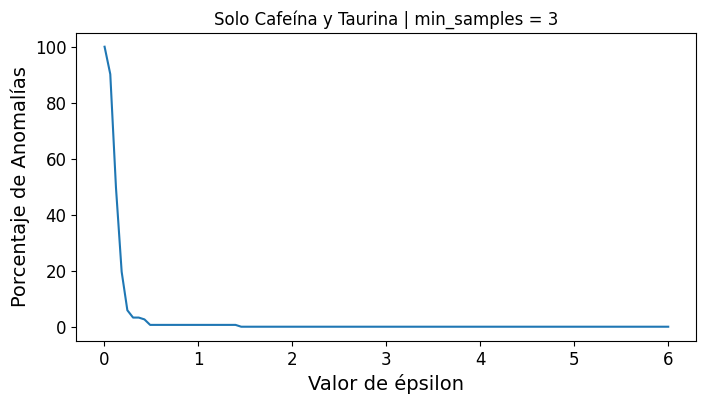

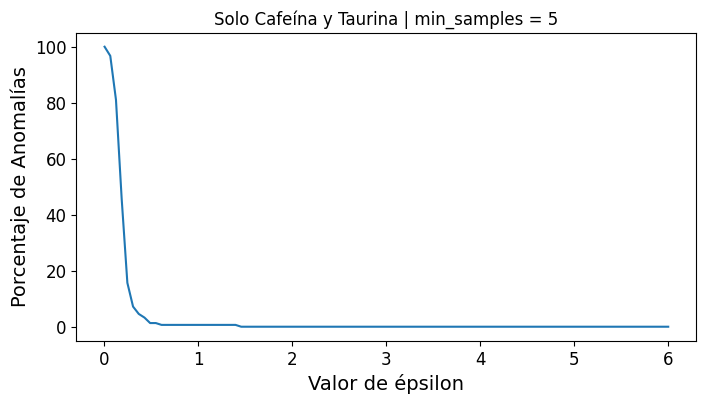

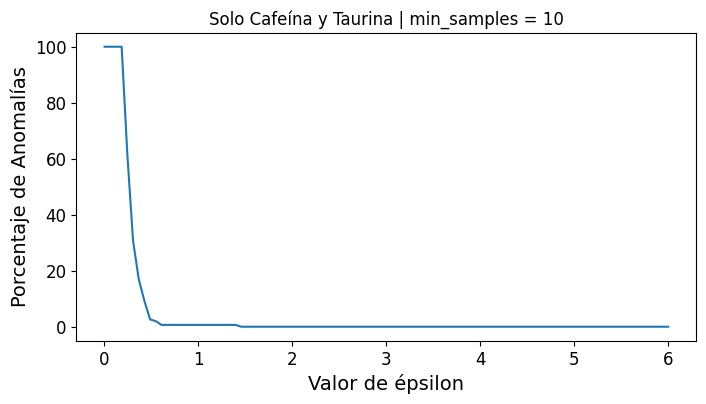

In [14]:
# Mismo barrido pero SOLO con Cafeina y Taurina
experiments_2f = {}

for min_samples in [3, 5, 10]:
    outlier_percent = []
    for eps in np.linspace(0.001, 6, 100):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set[features_short])
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        outlier_percent.append(perc_outliers)
    experiments_2f[min_samples] = outlier_percent
    print(f"min_samples = {min_samples} -> barrido hecho")

for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4), dpi=100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments_2f[min_samples])
    plt.ylabel("Porcentaje de Anomalías")
    plt.xlabel("Valor de épsilon")
    plt.title(f"Solo Cafeína y Taurina | min_samples = {min_samples}")
    plt.show()

In [15]:
# Probamos varias combinaciones y nos quedamos con la que de 3-5 clusters con pocas anomalias
print("eps  | min_samples | nº clusters | % anomalias")
print("-" * 48)
for eps in [0.3, 0.4, 0.5, 1.0]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set[features_short])
        n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
        perc = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        print(f"{eps:4} |     {min_samples:2}      |      {n_clusters}      |   {perc:.1f}%")

eps  | min_samples | nº clusters | % anomalias
------------------------------------------------
 0.3 |      3      |      3      |   3.3%
 0.3 |      5      |      4      |   7.8%
 0.3 |     10      |      3      |   32.0%
 0.4 |      3      |      2      |   2.6%
 0.4 |      5      |      2      |   3.3%
 0.4 |     10      |      3      |   10.5%
 0.5 |      3      |      2      |   0.7%
 0.5 |      5      |      2      |   1.3%
 0.5 |     10      |      2      |   2.6%
 1.0 |      3      |      1      |   0.7%
 1.0 |      5      |      1      |   0.7%
 1.0 |     10      |      1      |   0.7%


**Eleccion de hiperparametros:** nos quedamos con **`eps = 0.3` y `min_samples = 3`** (sobre Cafeina-Taurina) porque:
* da **3 clusters**, justo dentro de lo que esperan los quimicos (entre 3 y 5),
* con solo un **3.3% de anomalias** (muy poquitas), y
* `min_samples = 5` daria 4 clusters pero con mas del doble de anomalias (7.8%), y `min_samples = 10`
  se dispara a un 32% de anomalias (demasiado exigente para un dataset de solo 153 muestras).

#### 6. Entrenamiento y visualizacion de resultados

**DBSCAN**

In [16]:
dbscan_final = DBSCAN(eps=0.3, min_samples=3)
dbscan_final.fit(train_set[features_short])

train_set_2f = train_set.copy()
train_set_2f["Cluster"] = dbscan_final.labels_

print("Reparto de instancias por cluster (-1 = anomalia):")
print(train_set_2f["Cluster"].value_counts())

Reparto de instancias por cluster (-1 = anomalia):
Cluster
 0    65
 1    46
 2    37
-1     5
Name: count, dtype: int64


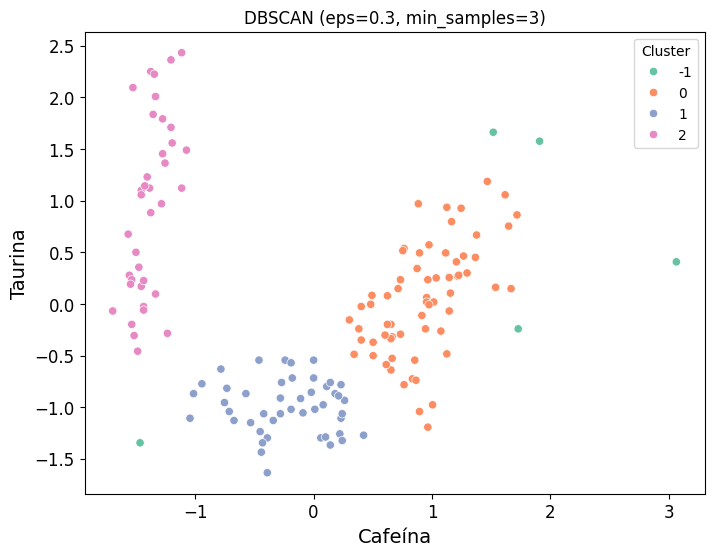

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_2f, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2")
plt.title("DBSCAN (eps=0.3, min_samples=3)")
plt.show()

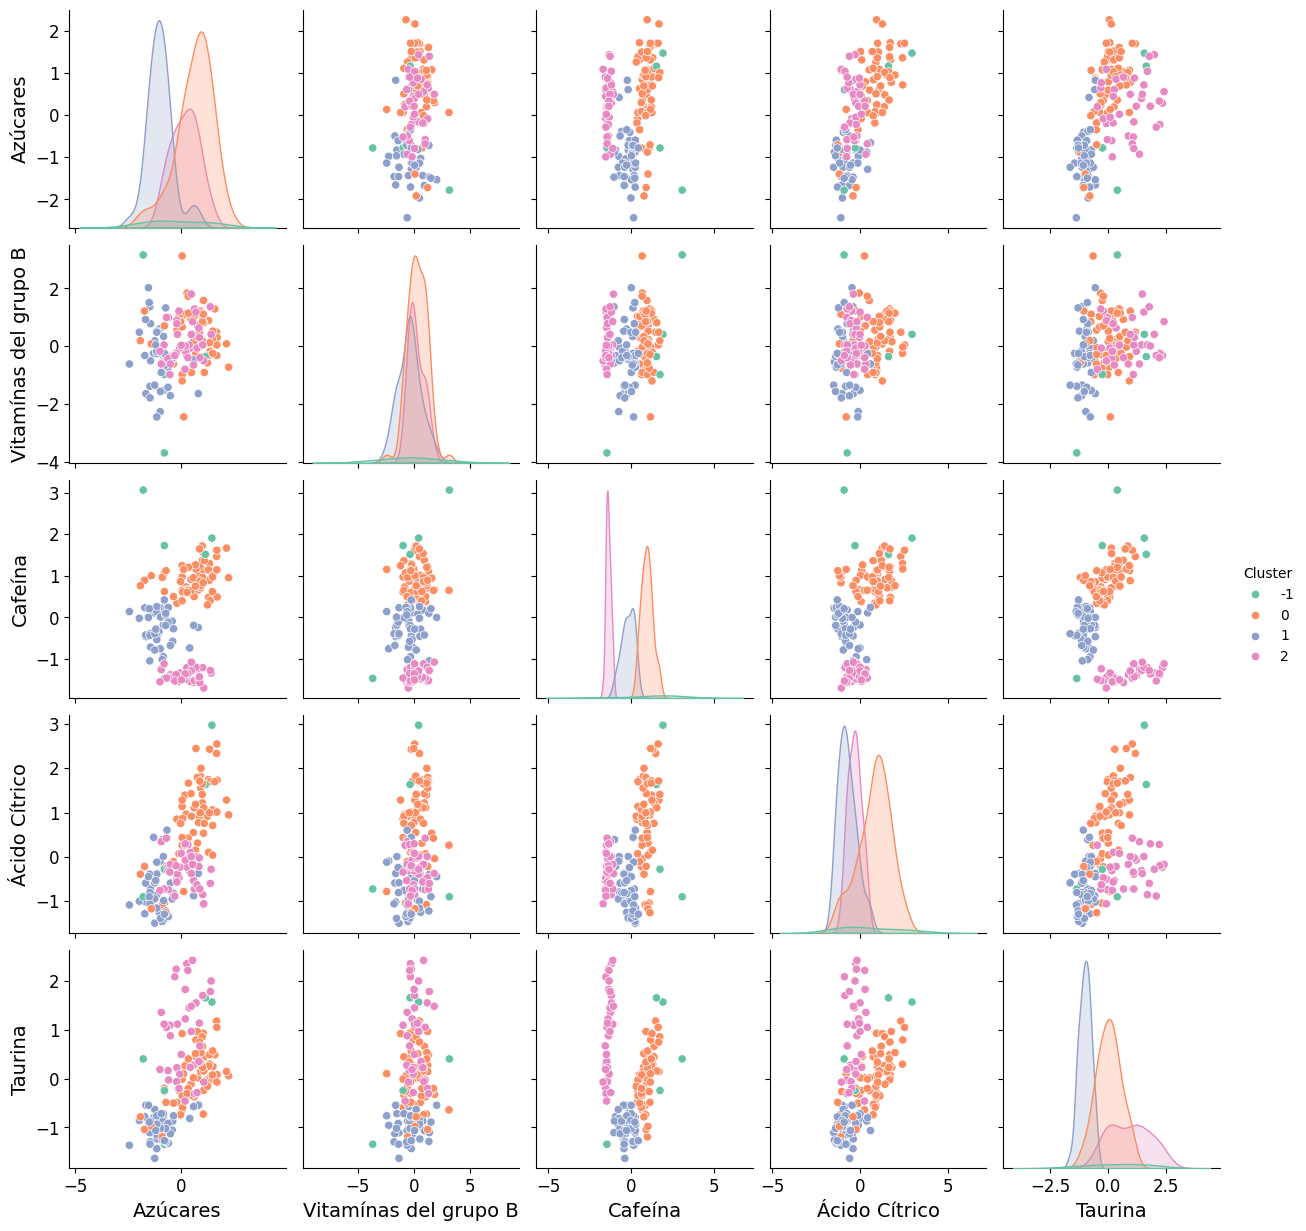

In [18]:
# Vemos como quedan los clusters en el resto de parejas de features
sns.pairplot(train_set_2f, hue="Cluster", palette="Set2")
plt.show()

**Clustering Jerarquico (Aglomerativo)**

*Este es el que nos da lo que pedian los quimicos "como extra": saber **que segmentos se parecen mas
entre si**. Empezamos por el dendrograma, que ademas nos ayuda a elegir el numero de clusters
(buscamos el mayor "salto"/gap vertical sin lineas horizontales que lo crucen).*

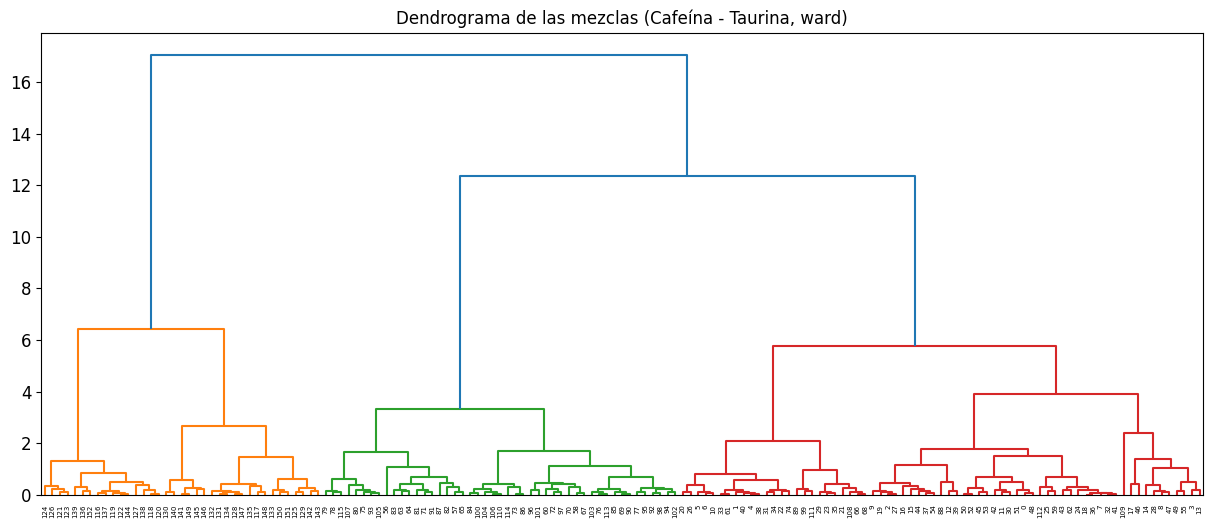

In [19]:
link_method = linkage(train_set[features_short], method="ward")

plt.figure(figsize=(15, 6))
dend = dendrogram(link_method)
plt.title("Dendrograma de las mezclas (Cafeína - Taurina, ward)")
plt.show()

In [20]:
# Las ultimas uniones del linkage nos dan las distancias a las que se fusionan los grandes clusters
# Columnas: [cluster_1, cluster_2, distancia, nº elementos]
print("Ultimas 5 uniones (las de mas arriba del dendrograma):")
print(link_method[-5:])

Ultimas 5 uniones (las de mas arriba del dendrograma):
[[295.         297.           3.91456299  44.        ]
 [296.         300.           5.7867262   69.        ]
 [289.         298.           6.42831329  37.        ]
 [299.         301.          12.34117438 116.        ]
 [302.         303.          17.05969203 153.        ]]


*El salto mas grande esta en la parte alta. Si cortamos por debajo de esa ultima union nos quedan
**3 clusters**, que coincide con lo que nos dio DBSCAN y con la expectativa de los quimicos. Lo pintamos.*

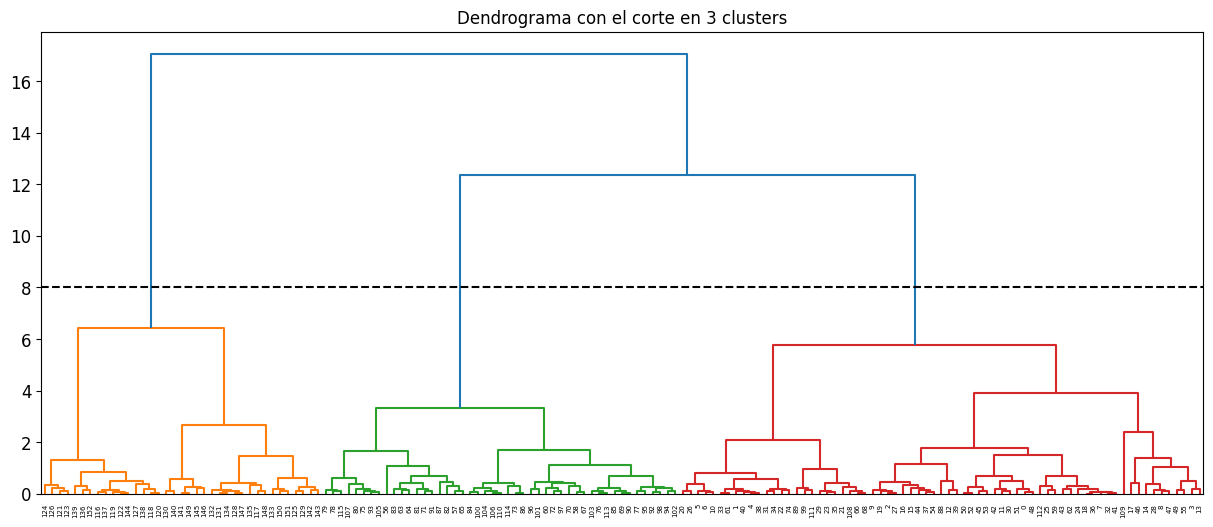

In [21]:
plt.figure(figsize=(15, 6))
dend = dendrogram(link_method)
plt.axhline(y=8, color="k", linestyle="--")   # corte que deja 3 clusters
plt.title("Dendrograma con el corte en 3 clusters")
plt.show()

In [22]:
clustering_model = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
clustering_model.fit(train_set[features_short])

train_set_agg = train_set.copy()
train_set_agg["Cluster"] = clustering_model.labels_

print("Reparto de instancias por cluster:")
print(train_set_agg["Cluster"].value_counts())

Reparto de instancias por cluster:
Cluster
1    69
2    47
0    37
Name: count, dtype: int64


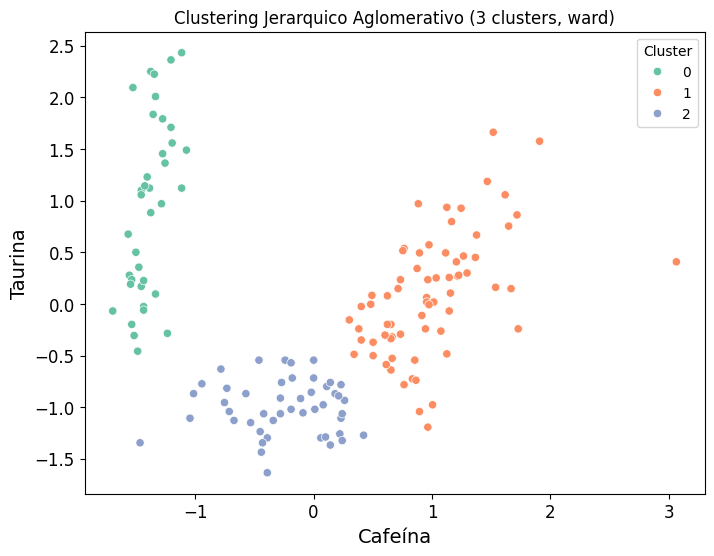

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_agg, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2")
plt.title("Clustering Jerarquico Aglomerativo (3 clusters, ward)")
plt.show()

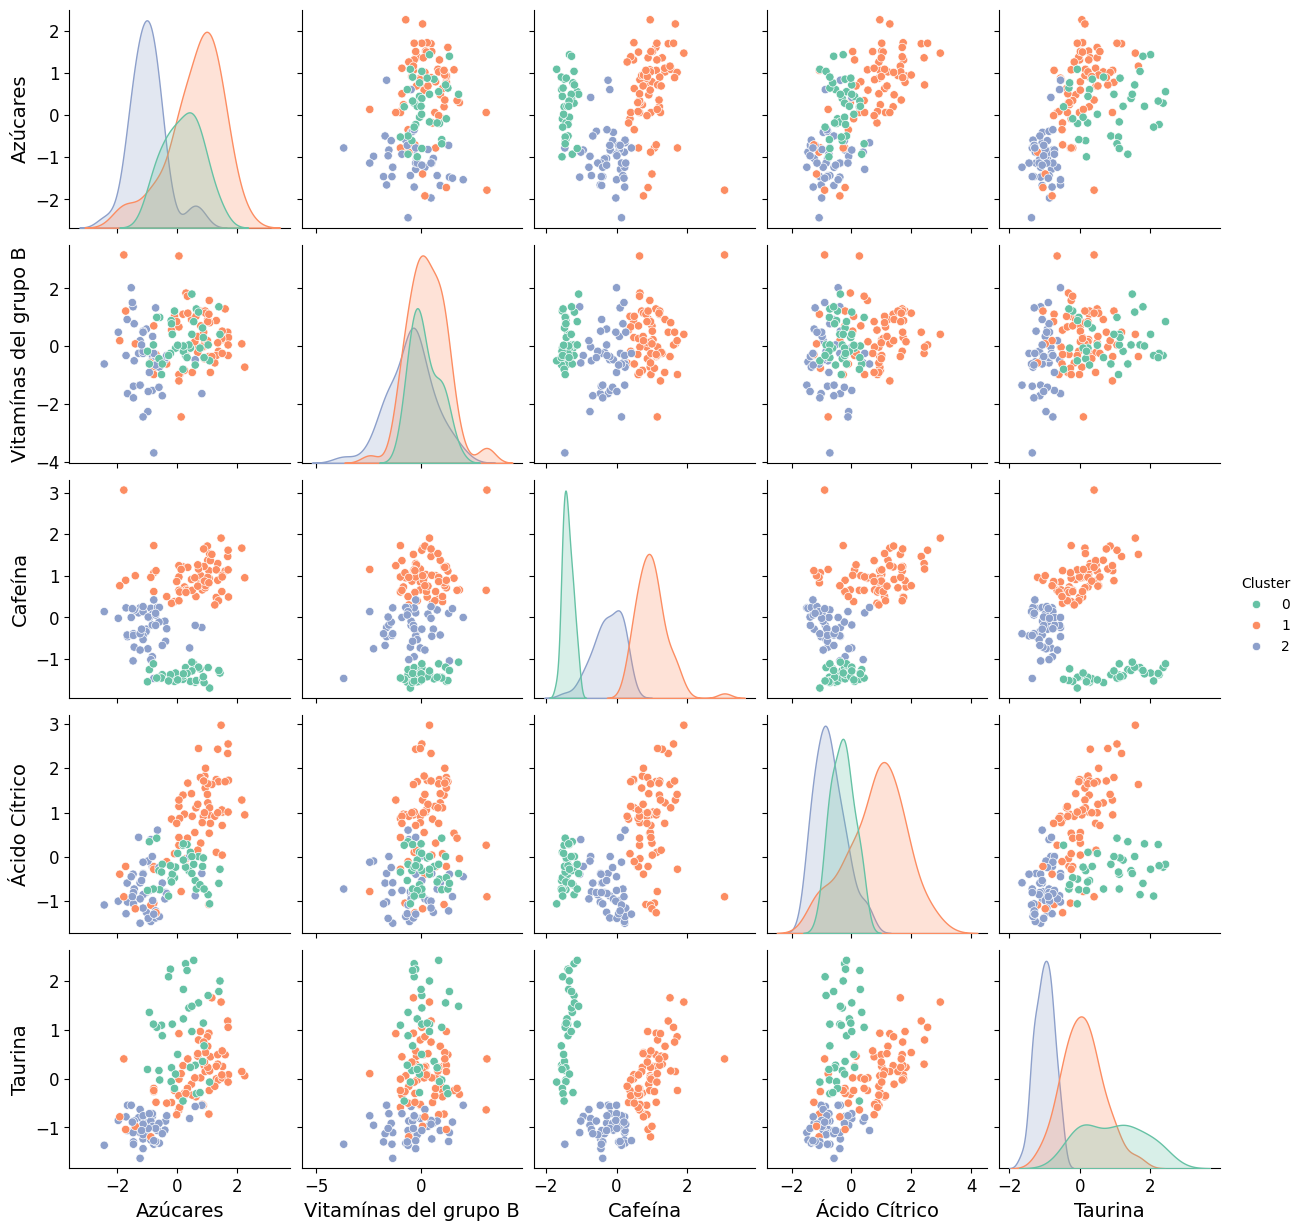

In [24]:
sns.pairplot(train_set_agg, hue="Cluster", palette="Set2")
plt.show()

#### 7. Discusion / comparacion de los dos modelos

In [25]:
# Comparamos las etiquetas de los dos algoritmos (ojo: los NUMEROS de cluster no tienen por que coincidir,
# lo que nos interesa es si AGRUPAN igual)
comparacion = train_set_2f.merge(train_set_agg,
                                 left_index=True, right_index=True,
                                 suffixes=["_DBSCAN", "_Agglo"])

print(comparacion[["Cluster_DBSCAN", "Cluster_Agglo"]].value_counts())

Cluster_DBSCAN  Cluster_Agglo
 0              1                65
 1              2                46
 2              0                37
-1              1                 4
                2                 1
Name: count, dtype: int64


**Comparacion:**

* Los dos algoritmos hacen **practicamente la misma agrupacion**: cada cluster de DBSCAN se corresponde
  casi 1 a 1 con uno del Aglomerativo (aunque con **otro numero de etiqueta**, que es arbitrario).
* La diferencia principal: **DBSCAN detecta anomalias** (-1), mezclas que no encajan en ninguna zona densa,
  mientras que el **Aglomerativo obliga a todas las mezclas a caer en algun cluster**.
* El **Aglomerativo nos da ademas la relacion entre segmentos** (lo que pedian los quimicos): mirando las
  distancias de las ultimas uniones del dendrograma vemos que dos de los clusters se fusionan entre si a
  una distancia mucho menor que la que les separa del tercero -> **esos dos se "parecen" mas entre si**.

**¿Por que la comparacion es especulativa?**

Porque **no tenemos target**. Sin una variable real de "capacidad antifatiga" no podemos calcular ninguna
metrica (accuracy, recall...) que diga cual de los dos clustering es "el correcto". Solo podemos decir que
ambos encuentran la misma estructura, que es coherente con lo que esperaban los quimicos (3 segmentos) y que
visualmente separa bien. **Quien tiene que dar sentido a los segmentos es negocio (los quimicos)**, no el algoritmo.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [26]:
X_new = pd.read_csv("./data/new_experiments.csv", sep="|")
X_new

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


*El enunciado dice "emplea el modelo que te resulte mas sencillo". Aqui hay un detalle importante que
vimos en el workout: **DBSCAN no tiene metodo `predict()`** y el **Aglomerativo tampoco**, asi que hay dos caminos:*

1. *Re-entrenar el clustering con el dataset viejo + el nuevo (lo tipico en jerarquico, pero te re-etiqueta todo).*
2. *Usar el dataset ya etiquetado por el clustering como **train de un clasificador supervisado** (lo que hicimos
   en el workout con un KNN). Esto es lo mas comodo: una vez entrenado, etiqueta cualquier mezcla nueva al vuelo.*

*Vamos con la opcion 2 (KNN sobre las etiquetas de DBSCAN) y luego comprobamos con la opcion 1 (jerarquico)
que ambos dicen lo mismo.*

**Opcion 2: KNN entrenado con las etiquetas de DBSCAN**

In [27]:
target = "Cluster"

# Entrenamos en el MISMO espacio en el que DBSCAN definio los clusters (Cafeina-Taurina)
X_train = train_set_2f[features_short]
y_train = train_set_2f[target]

param_grid = {
    "n_neighbors": [2, 3, 5, 10],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(KNeighborsClassifier(),
                        param_grid=param_grid,
                        cv=4,
                        scoring="balanced_accuracy")   # multiclase y todas las clases importan

knn_grid.fit(X_train, y_train)

print("Mejores hiperparametros:", knn_grid.best_params_)
print("Mejor balanced_accuracy en CV:", round(knn_grid.best_score_, 4))

Mejores hiperparametros: {'n_neighbors': 2, 'weights': 'distance'}
Mejor balanced_accuracy en CV: 0.8438


In [28]:
# Comprobamos que el KNN ha "copiado" bien el clustering de DBSCAN
print(classification_report(y_train, knn_grid.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         5
           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        46
           2       1.00      1.00      1.00        37

    accuracy                           1.00       153
   macro avg       1.00      1.00      1.00       153
weighted avg       1.00      1.00      1.00       153



*Ha copiado el clustering casi perfectamente. Aqui el "overfitting" **no es un problema sino lo que
buscamos**: no queremos generalizar a otra poblacion, queremos **reproducir exactamente la segmentacion que
hizo DBSCAN** para poder aplicarla a mezclas nuevas.*

In [29]:
# Etiquetamos los nuevos experimentos
X_new_dbscan = X_new.copy()
X_new_dbscan["Cluster_DBSCAN"] = knn_grid.best_estimator_.predict(X_new[features_short])
X_new_dbscan

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster_DBSCAN
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


**Opcion 1 (comprobacion): rehacemos el jerarquico con los datos viejos + los nuevos**

Shape con los nuevos experimentos: (159, 5)


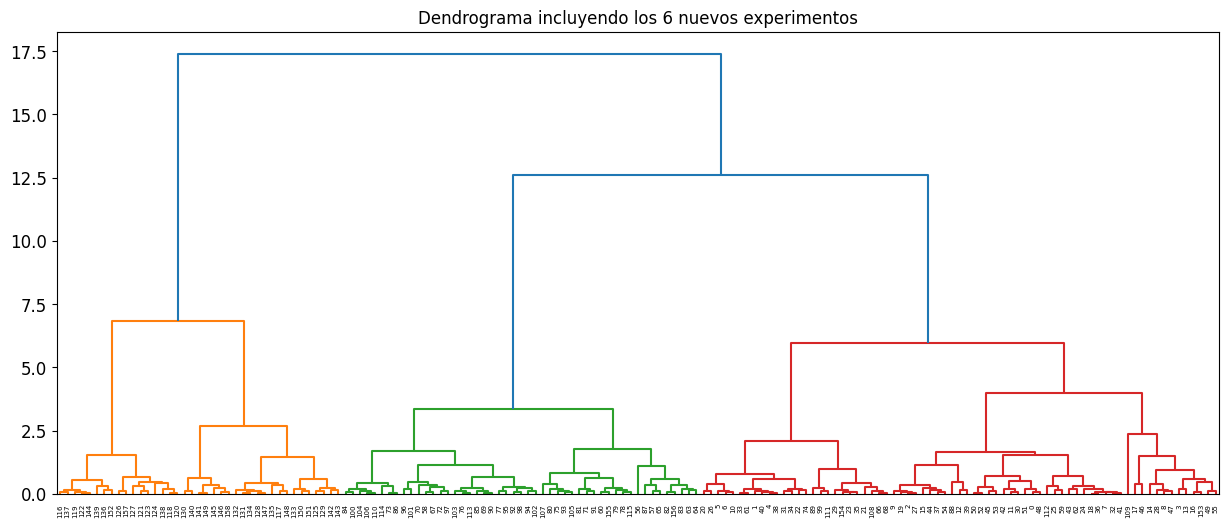

In [30]:
new_train_set = pd.concat([train_set, X_new], ignore_index=True)
print("Shape con los nuevos experimentos:", new_train_set.shape)

link_method_new = linkage(new_train_set[features_short], method="ward")
plt.figure(figsize=(15, 6))
dend = dendrogram(link_method_new)
plt.title("Dendrograma incluyendo los 6 nuevos experimentos")
plt.show()

*La estructura no ha cambiado, siguen viendose los mismos 3 grandes grupos. Sacamos las etiquetas.*

In [31]:
clustering_model_new = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
clustering_model_new.fit(new_train_set[features_short])

new_train_set_agg = new_train_set.copy()
new_train_set_agg["Cluster"] = clustering_model_new.labels_

# Los nuevos experimentos son las 6 ultimas filas
new_train_set_agg.tail(len(X_new))

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
153,1.481555,0.305159,1.366128,2.239039,0.731870,1
154,0.616869,0.890014,0.583034,0.312420,-0.665332,1
155,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
156,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
157,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0
158,0.962743,-0.243142,-1.354622,-0.420013,1.956043,0


In [ ]:
# ¿Coinciden las dos asignaciones? (nota: los numeros de etiqueta son arbitrarios)
comparacion_new = pd.DataFrame({
    "Cluster_DBSCAN_via_KNN": X_new_dbscan["Cluster_DBSCAN"].values,
    "Cluster_Agglomerativo": new_train_set_agg.tail(len(X_new))["Cluster"].values
})
comparacion_new

,Cluster_DBSCAN_via_KNN,Cluster_Agglomerativo
0,0,1
1,0,1
2,1,2
3,1,2
4,2,0
5,2,0


**Conclusion de la Parte II:** los dos enfoques **agrupan los 6 nuevos experimentos exactamente igual**
(por parejas: 1-2, 3-4, 5-6), aunque el numero de etiqueta que les pone cada algoritmo sea distinto.
Eso nos da confianza en la segmentacion. Se lo pasariamos a los quimicos para que le den significado.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

*¡Por fin tenemos target! Ahora SI podemos evaluar de verdad la segmentacion (dejando de ser especulativa).
El fichero tiene 159 filas = 153 experimentos iniciales + 6 nuevos, y en ese orden.*

In [33]:
df_results = pd.read_csv("./data/power_results.csv")
print("Shape:", df_results.shape)
print(df_results["class"].value_counts().sort_index())
df_results.head()

Shape: (159, 1)
class
1    58
2    62
3    39
Name: count, dtype: int64


,class
0,1
1,1
2,1
3,1
4,1


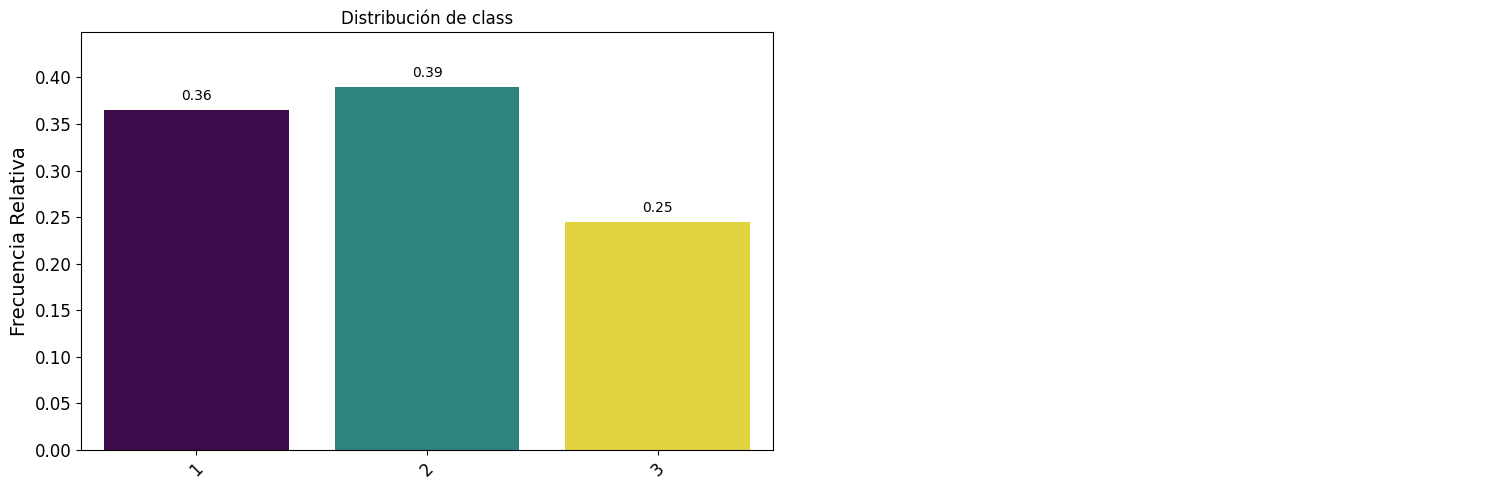

In [34]:
# El target va de 1 a 3 y nuestros clusters de 0 a 2 -> restamos 1 para poder compararlos
y_true = df_results["class"] - 1

bt.pinta_distribucion_categoricas(df_results, ["class"], mostrar_valores=True, relativa=True)

**Evaluacion de DBSCAN**

In [35]:
# Juntamos los 153 iniciales (ya etiquetados por DBSCAN) + los 6 nuevos (etiquetados via KNN)
full_dbscan = pd.concat([
    train_set_2f[features_short + ["Cluster"]],
    X_new_dbscan[features_short].assign(Cluster=X_new_dbscan["Cluster_DBSCAN"].values)
], ignore_index=True)

full_dbscan["true_class"] = y_true
print("Shape:", full_dbscan.shape)
full_dbscan.head()

Shape: (159, 4)


,Cafeína,Taurina,Cluster,true_class
0,1.034819,0.251717,0,0
1,0.733629,-0.293321,0,0
2,1.215533,0.269020,0,0
3,1.466525,1.186068,0,0
4,0.663351,-0.319276,0,0


In [ ]:
# las etiquetas de cluster son arbitrarias, no tienen por que coincidir con las del target.
# Antes de evaluar hay que ver a que clase real corresponde cada cluster -> tabla de contingencia
print("Filas = cluster de DBSCAN | Columnas = clase real")
pd.crosstab(full_dbscan["Cluster"], full_dbscan["true_class"])

Filas = cluster de DBSCAN | Columnas = clase real


true_class,0,1,2
Cluster,,,
-1,2,3,0
0,56,11,0
1,0,48,0
2,0,0,39


*La tabla nos dice el "diccionario" de traduccion entre cluster y clase real. Renombramos y evaluamos.
Las anomalias (-1) las dejamos fuera de la evaluacion, porque DBSCAN dice explicitamente
"esta mezcla no la clasifico".*

In [37]:
# Construimos el mapeo automaticamente: a cada cluster le asignamos la clase real mas frecuente en el
tabla = pd.crosstab(full_dbscan["Cluster"], full_dbscan["true_class"])
mapeo = tabla.idxmax(axis=1).to_dict()      # cluster -> clase real mayoritaria
print("Mapeo cluster -> clase real:", mapeo)

full_dbscan["pred_class"] = full_dbscan["Cluster"].map(mapeo)

# Quitamos las anomalias para evaluar
sin_anomalias = full_dbscan[full_dbscan["Cluster"] != -1]
print(f"\nEvaluamos {len(sin_anomalias)} de {len(full_dbscan)} mezclas "
      f"({len(full_dbscan) - len(sin_anomalias)} anomalias fuera)\n")

print(classification_report(sin_anomalias["true_class"], sin_anomalias["pred_class"]))

Mapeo cluster -> clase real: {-1: 1, 0: 0, 1: 1, 2: 2}

Evaluamos 154 de 159 mezclas (5 anomalias fuera)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        56
           1       1.00      0.81      0.90        59
           2       1.00      1.00      1.00        39

    accuracy                           0.93       154
   macro avg       0.95      0.94      0.94       154
weighted avg       0.94      0.93      0.93       154



**Evaluacion del Clustering Jerarquico**

In [38]:
full_agg = new_train_set_agg.copy()
full_agg["true_class"] = y_true

print("Filas = cluster Aglomerativo | Columnas = clase real")
display(pd.crosstab(full_agg["Cluster"], full_agg["true_class"]))

tabla_agg = pd.crosstab(full_agg["Cluster"], full_agg["true_class"])
mapeo_agg = tabla_agg.idxmax(axis=1).to_dict()
print("Mapeo cluster -> clase real:", mapeo_agg)

full_agg["pred_class"] = full_agg["Cluster"].map(mapeo_agg)
print()
print(classification_report(full_agg["true_class"], full_agg["pred_class"]))

Filas = cluster Aglomerativo | Columnas = clase real


true_class,0,1,2
Cluster,,,
0,0,0,39
1,58,13,0
2,0,49,0


Mapeo cluster -> clase real: {0: 2, 1: 0, 2: 1}

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        58
           1       1.00      0.79      0.88        62
           2       1.00      1.00      1.00        39

    accuracy                           0.92       159
   macro avg       0.94      0.93      0.93       159
weighted avg       0.93      0.92      0.92       159



#### Discusion final

* **La segmentacion no supervisada era buena.** Sin haber visto NUNCA el target, los dos clusterings
  reconstruyen en gran medida los tres niveles de "energizacion" que los quimicos midieron 6 meses despues.
  Es decir: la estructura que encontramos en los datos **era real**, no ruido.
* Esto valida a posteriori dos decisiones: quedarnos con **Cafeina y Taurina** (tienen que ver de verdad con
  el efecto energizante, lo cual tiene todo el sentido quimico) y pedir **3 segmentos**.
* **DBSCAN vs Jerarquico:** DBSCAN se "guarda" las mezclas raras como anomalias (no se moja con ellas), lo
  que sube su calidad sobre las que si clasifica pero deja algunas sin segmentar. El Aglomerativo clasifica
  todo, sin escaqueo, a costa de meter alguna mezcla rara en un cluster donde no encaja del todo.
* **Recuerda el matiz importante:** que ahora coincida con el target es una **suerte que solo podemos ver a
  posteriori**. En el momento de entregar el modelo (Parte I) la comparacion entre ambos era necesariamente
  especulativa, porque un algoritmo no supervisado **no puede saber si su agrupacion es "la correcta"**:
  solo encuentra estructura, el significado lo pone negocio.